<a href="https://colab.research.google.com/github/2007856reyli/act-y-pia/blob/main/AF%207%3A%20Proyecto%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Autónoma de Nuevo León

## Facultad de Ingeniería Mecánica y Eléctrica

### AF7 - Proyecto Final

## Simulación de un Robot Manipulador Plano de 2 GDL mediante Euler-Lagrange

**Alumno:** Reyli Isaac Morales Zarazua

**Matrícula:** 2007856

**Carrera:** IMC

## Diagrama del robot manipulador de 2 GDL

El siguiente diagrama representa un robot manipulador plano de dos grados de libertad. En él se muestran las variables involucradas, los sistemas de referencia y las articulaciones utilizadas para el modelado dinámico mediante el formalismo de Euler-Lagrange.

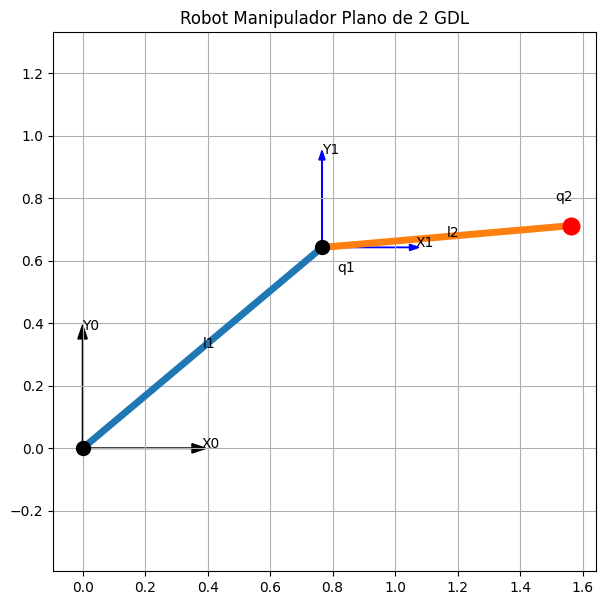

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Longitudes de los eslabones
l1 = 1
l2 = 0.8

# Ángulos únicamente para ilustrar el robot
q1 = np.deg2rad(40)
q2 = np.deg2rad(-35)

# Posiciones
x1 = l1*np.cos(q1)
y1 = l1*np.sin(q1)

x2 = x1 + l2*np.cos(q1+q2)
y2 = y1 + l2*np.sin(q1+q2)

plt.figure(figsize=(7,7))

# Robot
plt.plot([0,x1],[0,y1],linewidth=5)
plt.plot([x1,x2],[y1,y2],linewidth=5)

# Articulaciones
plt.plot(0,0,'ko',markersize=10)
plt.plot(x1,y1,'ko',markersize=10)
plt.plot(x2,y2,'ro',markersize=12)

# Sistemas de referencia
plt.arrow(0,0,0.35,0,
          head_width=0.03,
          color='black')
plt.arrow(0,0,0,0.35,
          head_width=0.03,
          color='black')

plt.text(0.38,0,"X0")
plt.text(0,0.38,"Y0")

plt.arrow(x1,y1,0.28,0,
          head_width=0.02,
          color='blue')

plt.arrow(x1,y1,0,0.28,
          head_width=0.02,
          color='blue')

plt.text(x1+0.30,y1,"X1")
plt.text(x1,y1+0.30,"Y1")

# Etiquetas
plt.text(x1/2,y1/2,"l1")
plt.text((x1+x2)/2,(y1+y2)/2,"l2")

plt.text(x1+0.05,y1-0.08,"q1")
plt.text(x2-0.05,y2+0.08,"q2")

plt.title("Robot Manipulador Plano de 2 GDL")

plt.axis('equal')
plt.grid(True)

plt.show()

## Importación de bibliotecas

Se importan las bibliotecas necesarias para realizar operaciones matemáticas, resolver el sistema de ecuaciones diferenciales y generar las gráficas de la simulación.

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Definición de los parámetros del robot

Se definen los parámetros del robot manipulador plano de dos grados de libertad, de acuerdo con el ejemplo 5.3 del libro de Fernando Reyes Cortés.

In [3]:
# Gravedad
g = 9.81

# Parámetros del robot

m1 = 1
m2 = 1

l1 = 1
l2 = 1

lc1 = 0.5
lc2 = 0.5

I1 = 1
I2 = 1

## Ecuación característica del sistema

Aplicando el formalismo de Euler-Lagrange al robot manipulador plano de dos grados de libertad se obtiene el modelo dinámico:

\[
M(q)\ddot q+C(q,\dot q)\dot q+G(q)+F(\dot q)=\tau
\]

donde:

- \(M(q)\) es la matriz de inercia.
- \(C(q,\dot q)\) representa los efectos centrífugos y de Coriolis.
- \(G(q)\) corresponde al vector de gravedad.
- \(F(\dot q)\) representa la fricción viscosa.
- \(\tau\) es el vector de torques aplicados por los motores.

## Representación en espacio de estados

Para resolver el sistema mediante integración numérica, se definen las siguientes variables de estado:

\[
x_1=q_1
\]

\[
x_2=q_2
\]

\[
x_3=\dot q_1
\]

\[
x_4=\dot q_2
\]

Por lo tanto,

\[
\dot x=
\begin{bmatrix}
\dot q_1\\
\dot q_2\\
\ddot q_1\\
\ddot q_2
\end{bmatrix}
\]

donde las aceleraciones articulares se obtienen a partir del modelo dinámico del robot.

## Definición de las matrices del modelo dinámico

A continuación se implementan las matrices del modelo dinámico del robot manipulador plano de dos grados de libertad, correspondientes al ejemplo 5.3 del libro de Fernando Reyes Cortés.

## Definición del torque aplicado

Se define el vector de torques aplicado por los motores de las dos articulaciones. Estos torques dependen del tiempo y representan las entradas del sistema dinámico.

In [4]:
def tau(t):

    tau1 = (1-np.exp(-0.8*t))*32.0 \
           + 56*np.sin(16*t+0.1) \
           + 12*np.sin(20*t+0.15)

    tau2 = (1-np.exp(-0.8*t))*1.2 \
           + 8*np.sin(26*t+0.08) \
           + 2*np.sin(12*t+0.34)

    return np.array([tau1,tau2])

## Modelo dinámico del robot

Se implementa la ecuación diferencial del robot manipulador utilizando las matrices de inercia, Coriolis, gravedad y fricción. A partir de ellas se calcula la aceleración angular de cada articulación.

In [5]:
def robot2gdl(t,x):

    # Posiciones
    q1 = x[0]
    q2 = x[1]

    # Velocidades
    qp1 = x[2]
    qp2 = x[3]

    qp = np.array([qp1,qp2])

    #==============================
    # Matriz de inercia
    #==============================

    M = np.array([
        [3.117+0.2*np.cos(q2),
         0.108+0.1*np.cos(q2)],

        [0.108+0.1*np.cos(q2),
         0.108]
    ])

    #==============================
    # Matriz de Coriolis
    #==============================

    C = np.array([
        [-0.2*np.sin(q2)*qp2,
         -0.1*np.sin(q2)*qp2],

        [0.1*np.sin(q2)*qp1,
         0]
    ])

    #==============================
    # Vector de gravedad
    #==============================

    G = np.array([
        39.3*np.sin(q1)+1.95*np.sin(q1+q2),
        1.95*np.sin(q1+q2)
    ])

    #==============================
    # Fricción
    #==============================

    F = np.array([
        1.86*qp1+1.93*np.sign(qp1),
        0.16*qp2+0.30*np.sign(qp2)
    ])

    #==============================
    # Torque
    #==============================

    T = tau(t)

    #==============================
    # Aceleración articular
    #==============================

    qpp = np.linalg.inv(M)@(T-C@qp-G-F)

    return [
        qp1,
        qp2,
        qpp[0],
        qpp[1]
    ]

## Configuración de la simulación

Se establece el intervalo de simulación, el tiempo total de análisis y las condiciones iniciales del robot manipulador.

In [6]:
ti = 0
tf = 10

h = 0.0025

t_eval = np.arange(ti,tf+h,h)

x0 = [
    0,      # q1
    0,      # q2
    0,      # q1 punto
    0       # q2 punto
]

## Resolución del sistema dinámico

Se utiliza el método numérico `solve_ivp` para resolver el sistema de ecuaciones diferenciales obtenido mediante Euler-Lagrange.

In [7]:
sol = solve_ivp(
    robot2gdl,
    [ti,tf],
    x0,
    t_eval=t_eval
)

t = sol.t

q1 = sol.y[0]
q2 = sol.y[1]

qp1 = sol.y[2]
qp2 = sol.y[3]

## Conversión de unidades

Las posiciones y velocidades articulares se convierten de radianes a grados para facilitar la interpretación de los resultados.

In [8]:
q1_deg = np.rad2deg(q1)
q2_deg = np.rad2deg(q2)

qp1_deg = np.rad2deg(qp1)
qp2_deg = np.rad2deg(qp2)

## Gráficas de la simulación

Se muestran las gráficas correspondientes a la posición y velocidad angular de cada una de las articulaciones del robot manipulador durante los 10 segundos de simulación.

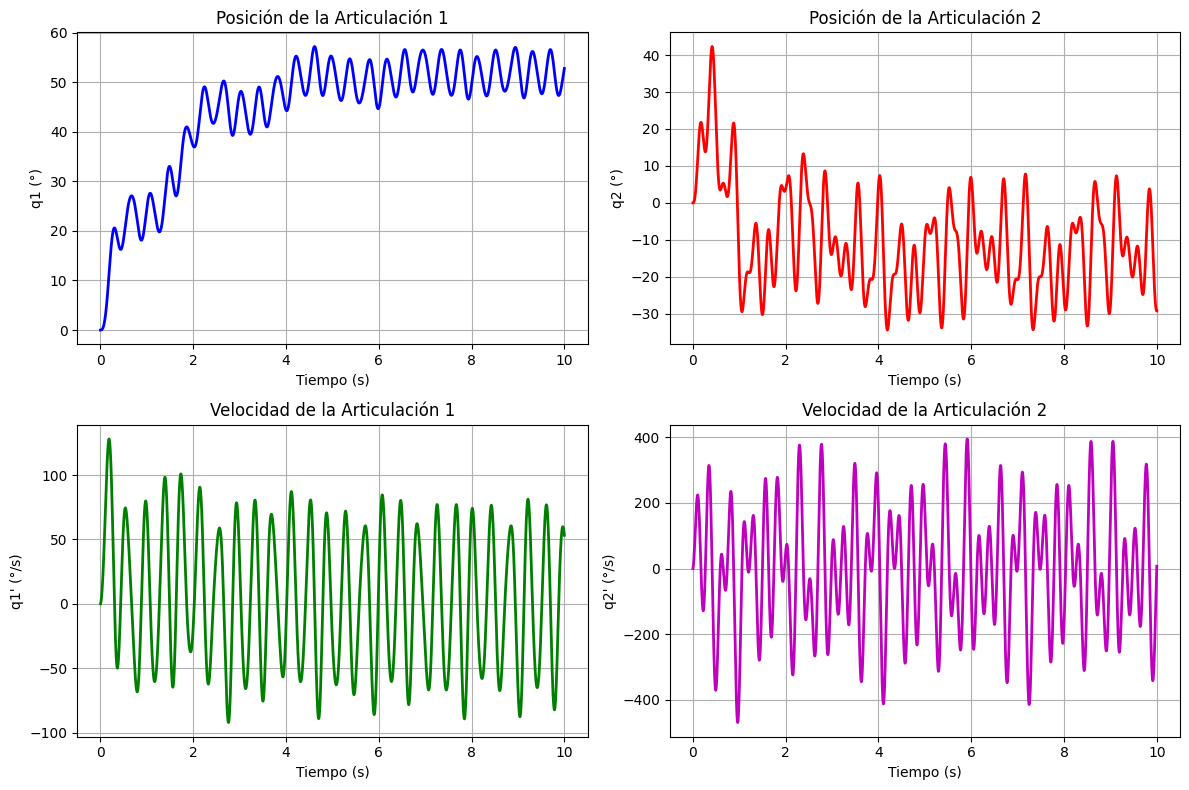

In [9]:
fig,ax=plt.subplots(2,2,figsize=(12,8))

#=========================
# Posición q1
#=========================

ax[0,0].plot(t,q1_deg,'b',linewidth=2)

ax[0,0].set_title("Posición de la Articulación 1")

ax[0,0].set_xlabel("Tiempo (s)")
ax[0,0].set_ylabel("q1 (°)")
ax[0,0].grid()

#=========================
# Posición q2
#=========================

ax[0,1].plot(t,q2_deg,'r',linewidth=2)

ax[0,1].set_title("Posición de la Articulación 2")

ax[0,1].set_xlabel("Tiempo (s)")
ax[0,1].set_ylabel("q2 (°)")
ax[0,1].grid()

#=========================
# Velocidad q1
#=========================

ax[1,0].plot(t,qp1_deg,'g',linewidth=2)

ax[1,0].set_title("Velocidad de la Articulación 1")

ax[1,0].set_xlabel("Tiempo (s)")
ax[1,0].set_ylabel("q1' (°/s)")
ax[1,0].grid()

#=========================
# Velocidad q2
#=========================

ax[1,1].plot(t,qp2_deg,'m',linewidth=2)

ax[1,1].set_title("Velocidad de la Articulación 2")

ax[1,1].set_xlabel("Tiempo (s)")
ax[1,1].set_ylabel("q2' (°/s)")
ax[1,1].grid()

plt.tight_layout()

plt.show()

## Animación del robot manipulador

Se representa el movimiento del robot manipulador plano de dos grados de libertad a partir de los resultados obtenidos durante la simulación.

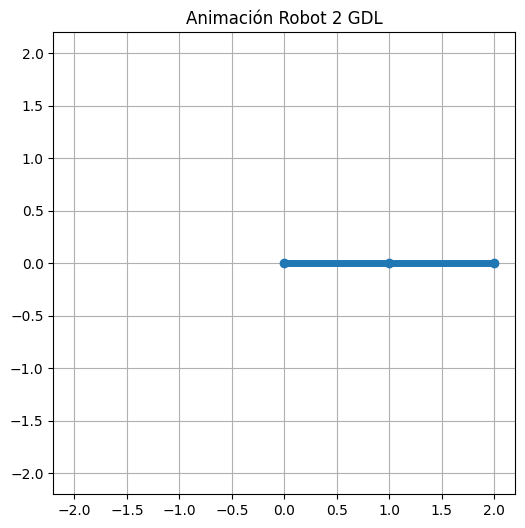

In [10]:
from matplotlib.animation import FuncAnimation

fig=plt.figure(figsize=(6,6))

ax=plt.axes(xlim=(-2.2,2.2),
            ylim=(-2.2,2.2))

ax.set_aspect("equal")
ax.grid()

line,=ax.plot([],[],'o-',lw=5)

l1=1
l2=1

def actualizar(i):

    x0=0
    y0=0

    x1=l1*np.cos(q1[i])
    y1=l1*np.sin(q1[i])

    x2=x1+l2*np.cos(q1[i]+q2[i])
    y2=y1+l2*np.sin(q1[i]+q2[i])

    line.set_data([x0,x1,x2],[y0,y1,y2])

    return line,

ani=FuncAnimation(
    fig,
    actualizar,
    frames=len(t),
    interval=10,
    blit=True
)

plt.title("Animación Robot 2 GDL")

plt.show()

## Resultados finales

Se presentan los valores finales obtenidos para la posición y velocidad angular de ambas articulaciones al concluir la simulación.

In [11]:
print("=========================================")
print("RESULTADOS FINALES")
print("=========================================")

print()

print("Articulación 1")
print("Posición =",q1_deg[-1],"°")
print("Velocidad =",qp1_deg[-1],"°/s")

print()

print("Articulación 2")
print("Posición =",q2_deg[-1],"°")
print("Velocidad =",qp2_deg[-1],"°/s")

RESULTADOS FINALES

Articulación 1
Posición = 52.7633964623455 °
Velocidad = 53.24740457663652 °/s

Articulación 2
Posición = -29.266038448934424 °
Velocidad = 7.124481235718997 °/s
